библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,  mean_absolute_error

подгрузка датасета

In [25]:
ds = pd.read_csv('probe.csv')
ds

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


распределения признаков

<Axes: >

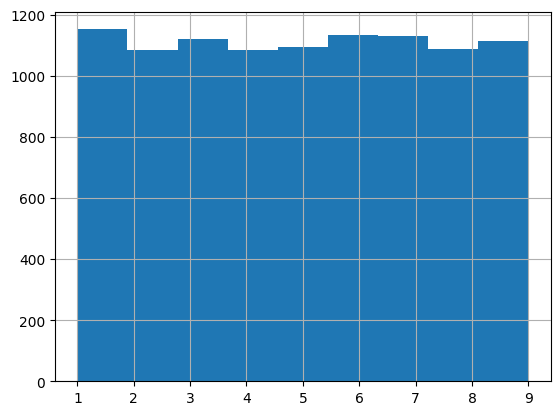

In [35]:
ds['Hours Studied'].hist(bins=9)

<Axes: >

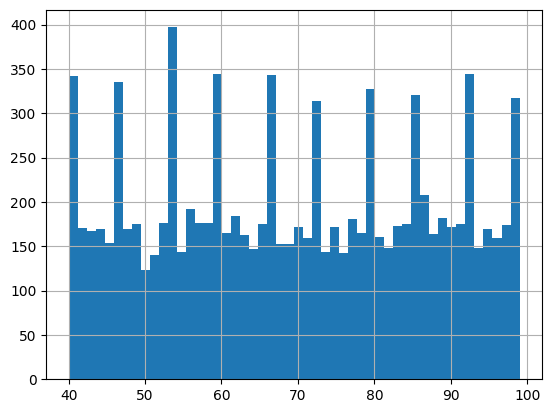

In [27]:
ds['Previous Scores'].hist(bins=50)

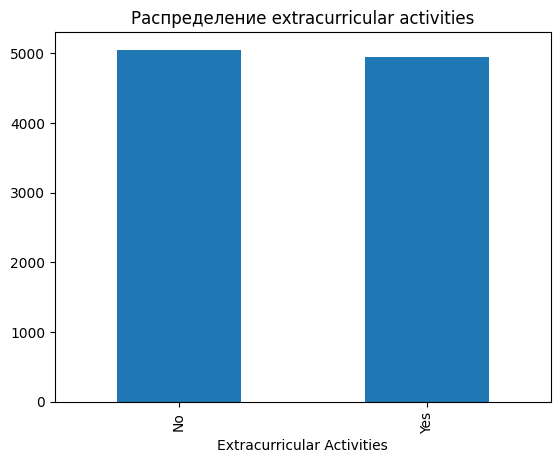

In [33]:
ds['Extracurricular Activities'].value_counts().plot(kind='bar')
plt.title('Распределение extracurricular activities')
plt.show()

<Axes: >

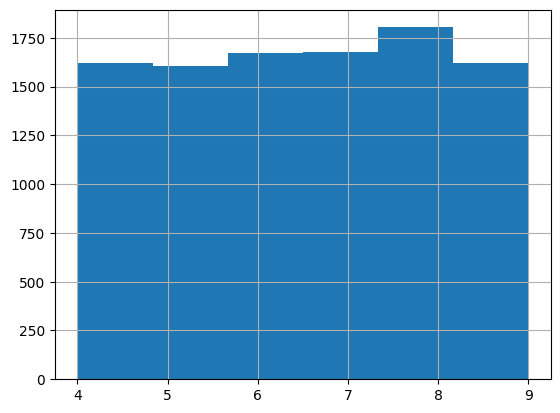

In [31]:
ds['Sleep Hours'].hist(bins=6)

<Axes: >

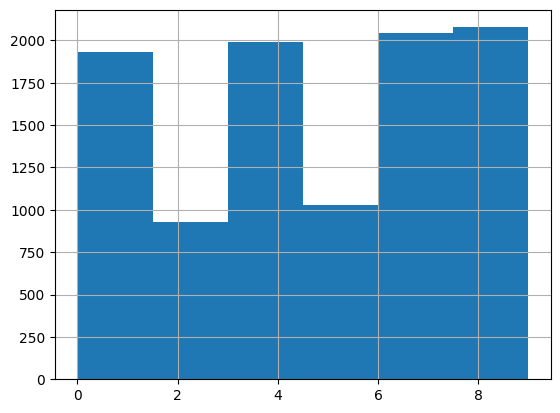

In [32]:
ds['Sample Question Papers Practiced'].hist(bins=6)

#Проверка на наличие выбросов

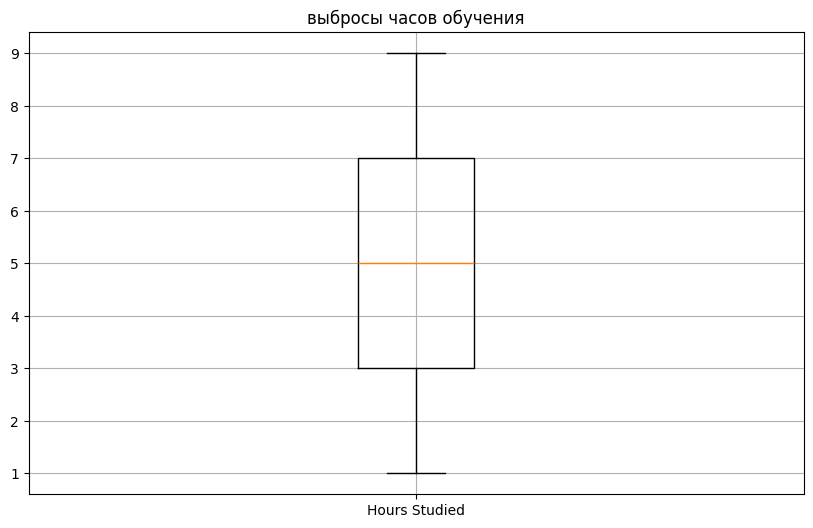

In [37]:
plt.figure(figsize=(10, 6))
plt.boxplot([ds['Hours Studied']], tick_labels=['Hours Studied'])
plt.title('выбросы часов обучения')
plt.grid(True)
plt.show()

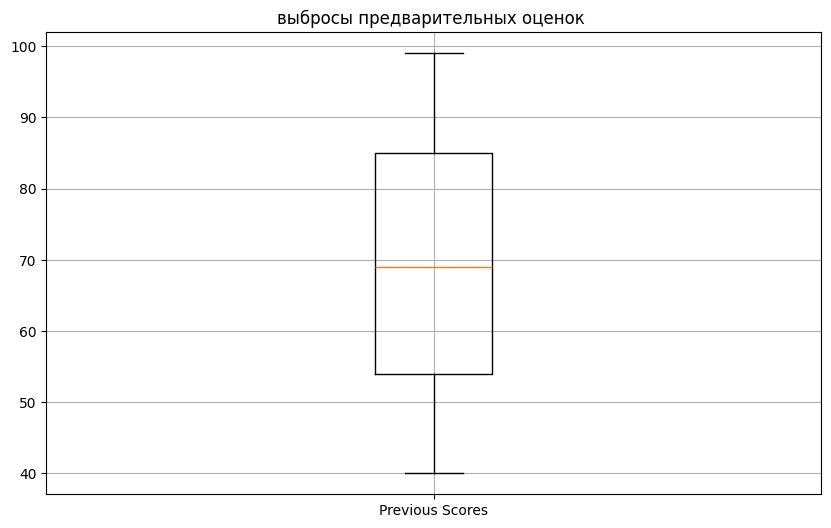

In [38]:
plt.figure(figsize=(10, 6))
plt.boxplot([ds['Previous Scores']], tick_labels=['Previous Scores'])
plt.title('выбросы предварительных оценок ')
plt.grid(True)
plt.show()

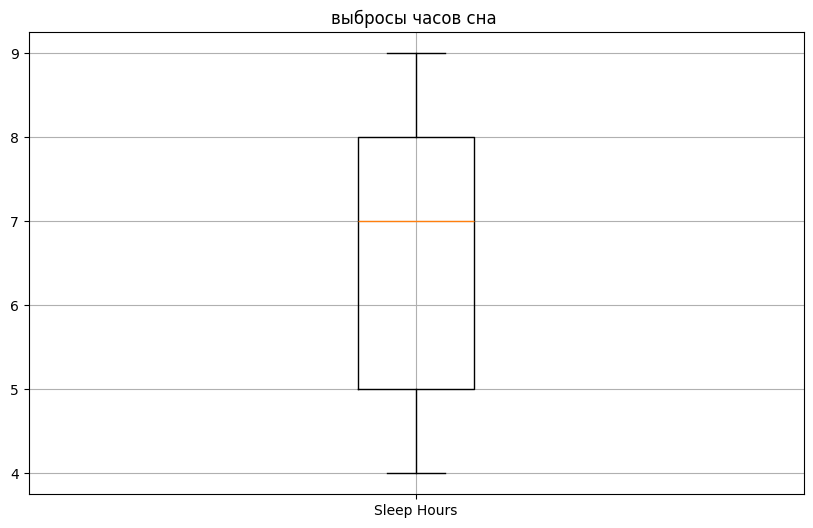

In [39]:
plt.figure(figsize=(10, 6))
plt.boxplot([ds['Sleep Hours']], tick_labels=['Sleep Hours'])
plt.title('выбросы часов сна ')
plt.grid(True)
plt.show()

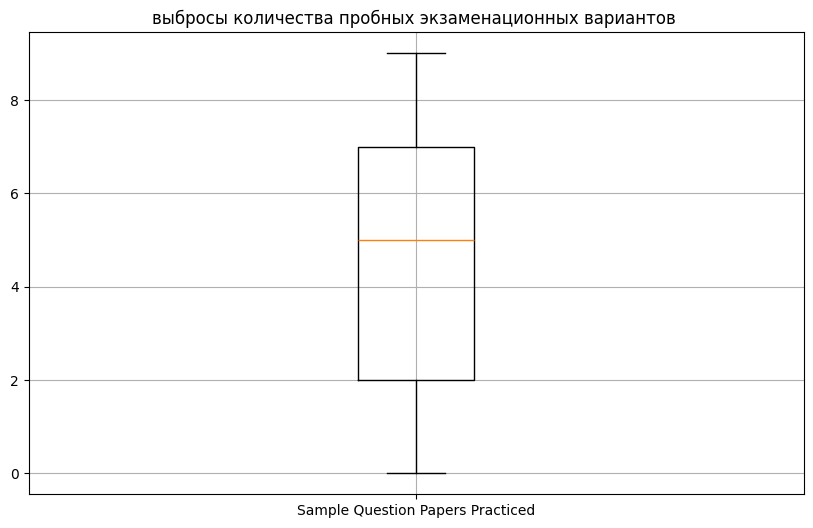

In [42]:
plt.figure(figsize=(10, 6))
plt.boxplot([ds['Sample Question Papers Practiced']], tick_labels=['Sample Question Papers Practiced'])
plt.title('выбросы количества пробных экзаменационных вариантов ')
plt.grid(True)
plt.show()

Избавление от выбросов

In [43]:
col = ['Hours Studied', 'Previous Scores','Sleep Hours', 'Sample Question Papers Practiced']
ds_clean = ds.copy()
for c in col:
    Q1 = ds_clean[c].quantile(0.25)
    Q3 = ds_clean[c].quantile(0.75)
    IQR = Q3 - Q1
    ds_clean = ds_clean[ds_clean[c].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)]

ds.shape[0], ds_clean.shape[0]

(10000, 10000)

Выбросы в данных не обнаружены, поэтому размер выборки не изменился, и дальнейший анализ проводился на исходном датафрейме.

Разделение на признаки

In [55]:
ds = ds.replace({"Yes": 1, "No": 0})
x = ds[['Hours Studied', 'Previous Scores','Sleep Hours', 'Extracurricular Activities', 'Sample Question Papers Practiced']]
y = ds['Performance Index']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

ds.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


In [56]:
model = LinearRegression()
model.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Метрики

In [57]:
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Метрики: RMSE", mse**0.5,"| R^2 ", r2, "| MAE ",mae)


Метрики: RMSE 2.049394596600869 | R^2  0.9887189383218594 | MAE  1.630328409478933


график обучения

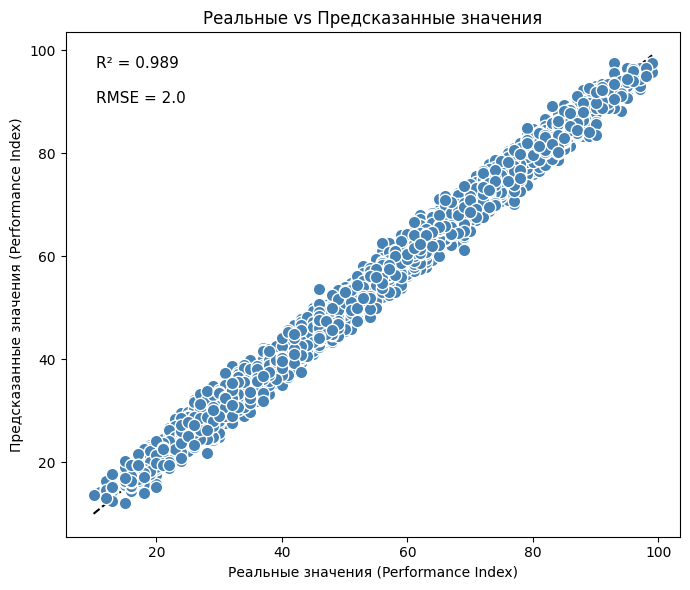

In [58]:
y_pred = model.predict(x_test)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

ax.scatter(y_test, y_pred, color='steelblue', edgecolors='white', s=80, zorder=3)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]
ax.plot(lims, lims, 'k--', linewidth=1.5)

ax.set_xlabel('Реальные значения (Performance Index)')
ax.set_ylabel('Предсказанные значения (Performance Index)')
ax.set_title('Реальные vs Предсказанные значения')

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

ax.text(0.05, 0.93, f'R² = {r2:.3f}', transform=ax.transAxes, fontsize=11)
ax.text(0.05, 0.86, f'RMSE = {rmse:.1f}', transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.show()